<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-9 - Wait-Attention (Flat-Trend) - Gold - LSTM </h1> </html>

## Gold  - Period: 01/01/2024 - 30/06/2024
5-minutes time-frame
     
### Predictions of Flat-Trend
- Early-Stopping
- Loss function: BinaryCrossentropy
- Metrics: Accuracy and (F1, Precision, Recall)

### length of analysed history (sliding window)- 50 raws ago

#### dataset: 35232 rows (5-minutes)
#### use part of the dataset: 12000 rows, which is around 2 months
#### train / test = 90 /10

#### Parameters

epoch = 30

patience = 10

take-profit = $10

hours = 4

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [1]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

'cat' is not recognized as an internal or external command,
operable program or batch file.


### Hint:

You can copy many blocks of text in the cells from the previous 2 weeks of practice sessions.
Some are easy enough to copy, some need to be slightly modified. In any case, this can speed up your code creation.

______________________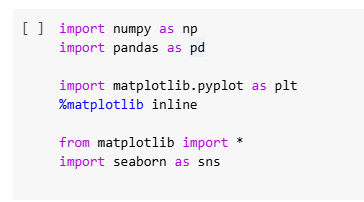

In [2]:
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import *
import seaborn as sns


_______________________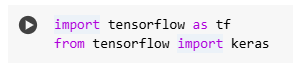

In [3]:
#
import tensorflow as tf
from tensorflow import keras

______________________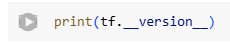

In [4]:
#
print(tf.__version__)

2.17.0


______________________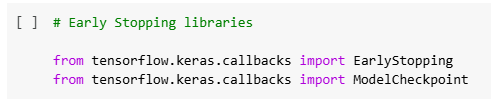

In [5]:
#
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

________________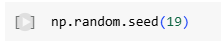

In [6]:
#
np.random.seed(19)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [7]:
# Use code in this cell for Google Colab only

# Run the cell twice and upload 2 files:
# XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv
# XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv

from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

_________________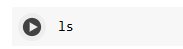

In [ ]:
# Here, you should see the 2 files mentioned above.

 sample_data/                                   XAUUSD_Daily_Ask_2024.01.01_2024.06.30.csv
'XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv'   XAUUSD_Hourly_Ask_2024.01.01_2024.06.30.csv
'XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv'


___________________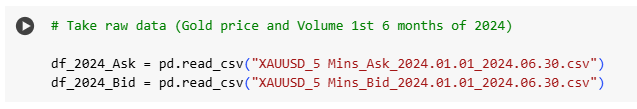

In [8]:
#
df_2024_Ask = pd.read_csv('XAUUSD_5 Mins_Ask_2024.01.01_2024.06.30.csv')
df_2024_Bid = pd.read_csv('XAUUSD_5 Mins_Bid_2024.01.01_2024.06.30.csv')



______________________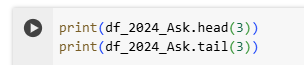

In [9]:
print(df_2024_Ask.head(3))
print(df_2024_Ask.tail(3))

            Time (UTC)      Open      High       Low     Close  Volume 
0  2024.01.01 23:00:00  2064.562  2067.475  2064.075  2065.686  0.11843
1  2024.01.01 23:05:00  2065.616  2065.839  2064.476  2064.902  0.06906
2  2024.01.01 23:10:00  2064.902  2066.825  2064.752  2066.105  0.04203
                Time (UTC)      Open      High       Low     Close  Volume 
35229  2024.06.30 23:45:00  2326.026  2326.315  2325.875  2325.945  0.02538
35230  2024.06.30 23:50:00  2325.945  2325.945  2325.555  2325.795  0.02880
35231  2024.06.30 23:55:00  2325.825  2325.835  2325.066  2325.245  0.07257


In [10]:
#

________________________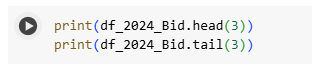

In [11]:
print(df_2024_Bid.head(3))
print(df_2024_Bid.tail(3))

            Time (UTC)      Open      High       Low     Close  Volume 
0  2024.01.01 23:00:00  2062.598  2066.595  2062.405  2065.214  0.12012
1  2024.01.01 23:05:00  2065.185  2065.194  2063.851  2064.455  0.06508
2  2024.01.01 23:10:00  2064.424  2066.365  2064.395  2065.734  0.03945
                Time (UTC)      Open      High       Low     Close  Volume 
35229  2024.06.30 23:45:00  2325.645  2325.905  2325.465  2325.525  0.06891
35230  2024.06.30 23:50:00  2325.515  2325.525  2325.125  2325.385  0.09813
35231  2024.06.30 23:55:00  2325.438  2325.438  2324.625  2324.825  0.07851


In [12]:
#

<html> <h3 style="font-style:italic; color:blue;"> Merge DataFrame </h3> </html>

___________________________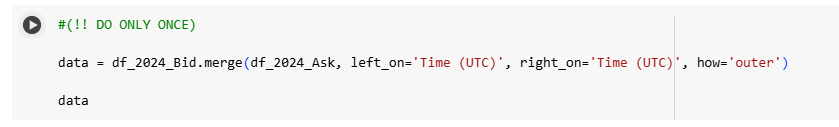

In [13]:
data = df_2024_Bid.merge(df_2024_Ask, left_on = 'Time (UTC)', right_on = 'Time (UTC)', how = 'outer')

In [14]:
#

________________________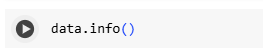

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time (UTC)  35232 non-null  object 
 1   Open_x      35232 non-null  float64
 2   High_x      35232 non-null  float64
 3   Low_x       35232 non-null  float64
 4   Close_x     35232 non-null  float64
 5   Volume _x   35232 non-null  float64
 6   Open_y      35232 non-null  float64
 7   High_y      35232 non-null  float64
 8   Low_y       35232 non-null  float64
 9   Close_y     35232 non-null  float64
 10  Volume _y   35232 non-null  float64
dtypes: float64(10), object(1)
memory usage: 3.0+ MB


In [16]:
#

In [17]:
# No NaN elements !

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [18]:
# rename columns

data.columns = ['Local time', 'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                   'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask']

_______________________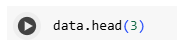

In [19]:
data.head(3)

,Local time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203


In [20]:
#

__________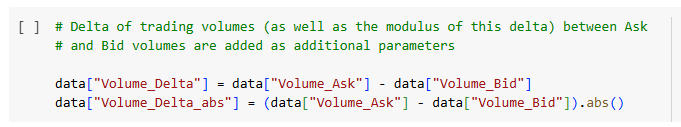

In [21]:
data["Volume_Delta"] = data["Volume_Ask"] - data["Volume_Bid"]
data["Volume_Delta_abs"] = (data["Volume_Ask"] - data["Volume_Bid"]).abs()

In [22]:
#


_______________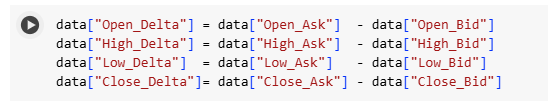

In [23]:
data["Open_Delta"] = data["Open_Ask"] - data['Open_Bid']
data['High_Delta'] = data['High_Ask'] - data['High_Bid']
data['Low_Delta'] = data['Low_Ask'] - data['Low_Bid']
data["Close_Delta"] = data['Close_Ask'] - data['Close_Bid']

In [24]:
#

____________________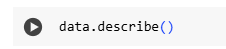

In [25]:
data.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
count,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000,35232.000000
mean,2205.889710,2206.645921,2205.128739,2205.897065,0.152156,2206.249356,2207.005264,2205.487844,2206.256846,0.152062,-0.000094,0.085480,0.359646,0.359343,0.359105,0.359781
std,142.978742,143.165839,142.780793,142.978152,0.159003,143.005802,143.192352,142.808660,143.005909,0.156439,0.130376,0.098443,0.105919,0.085914,0.090534,0.086697
min,1985.635000,1986.595000,1984.088000,1985.625000,0.000000,1985.915000,1986.945000,1984.475000,1985.915000,0.000000,-1.064400,0.000000,0.001000,0.042000,0.001000,0.075000
25%,2035.855000,2036.333250,2035.385000,2035.855000,0.046255,2036.195000,2036.675000,2035.722000,2036.195000,0.049140,-0.051012,0.017700,0.317000,0.320000,0.320000,0.320000
50%,2255.281500,2256.425000,2254.270000,2255.301500,0.098350,2255.650000,2256.758500,2254.608500,2255.660000,0.101700,0.001105,0.052920,0.350000,0.350000,0.350000,0.350000
75%,2333.475000,2334.292250,2332.639750,2333.477500,0.199250,2333.878250,2334.685250,2333.005000,2333.886750,0.196412,0.054670,0.118320,0.387000,0.387000,0.387000,0.387000
max,2449.735000,2449.985000,2447.555000,2449.758000,1.485490,2450.185000,2450.325000,2447.966000,2450.165000,2.842680,2.703590,2.703590,5.981000,5.981000,5.981000,5.981000


In [26]:
#

_______________________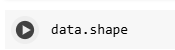

In [27]:
data.shape

(35232, 17)

In [28]:
#

_________________________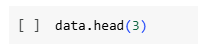

In [29]:
data.head(3)

,Local time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
0,2024.01.01 23:00:00,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472
1,2024.01.01 23:05:00,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447
2,2024.01.01 23:10:00,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371


In [30]:
#

<html> <h3 style="font-style:italic; color:blue;"> Date transformation </h3> </html>

______________________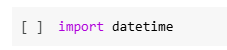

In [31]:
import datetime

In [32]:
#

_________________________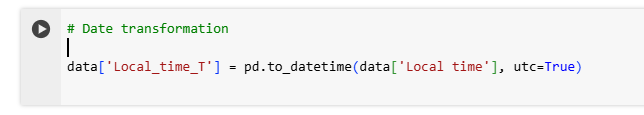

In [33]:
data['Local_time_T'] = pd.to_datetime(data['Local time'], utc=True)

In [34]:
#

________________________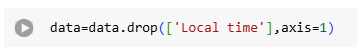

In [35]:
data = data.drop(['Local time'], axis=1)

In [36]:
#

_______________________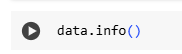

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Open_Bid          35232 non-null  float64            
 1   High_Bid          35232 non-null  float64            
 2   Low_Bid           35232 non-null  float64            
 3   Close_Bid         35232 non-null  float64            
 4   Volume_Bid        35232 non-null  float64            
 5   Open_Ask          35232 non-null  float64            
 6   High_Ask          35232 non-null  float64            
 7   Low_Ask           35232 non-null  float64            
 8   Close_Ask         35232 non-null  float64            
 9   Volume_Ask        35232 non-null  float64            
 10  Volume_Delta      35232 non-null  float64            
 11  Volume_Delta_abs  35232 non-null  float64            
 12  Open_Delta        35232 non-null  float64            
 13  H

In [38]:
#

<html> <h3 style="font-style:italic; color:blue;"> Data Visualisation </h3> </html>

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

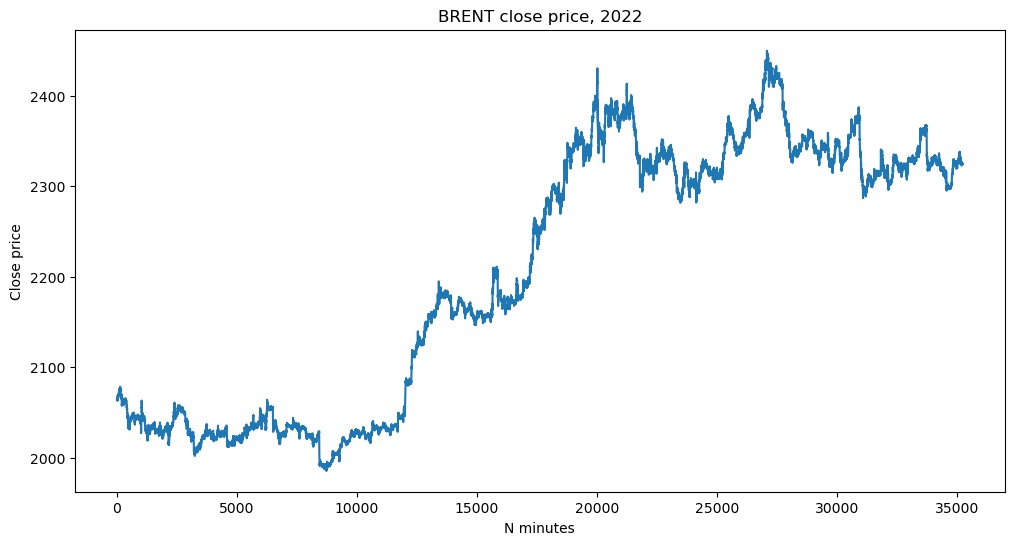

In [39]:
plt.figure(figsize=(12,6))
plt.plot(data['Close_Bid'])
plt.title('BRENT close price, 2022')
plt.xlabel('N minutes')
plt.ylabel('Close price')
plt.show()

<Figure size 900x400 with 0 Axes>

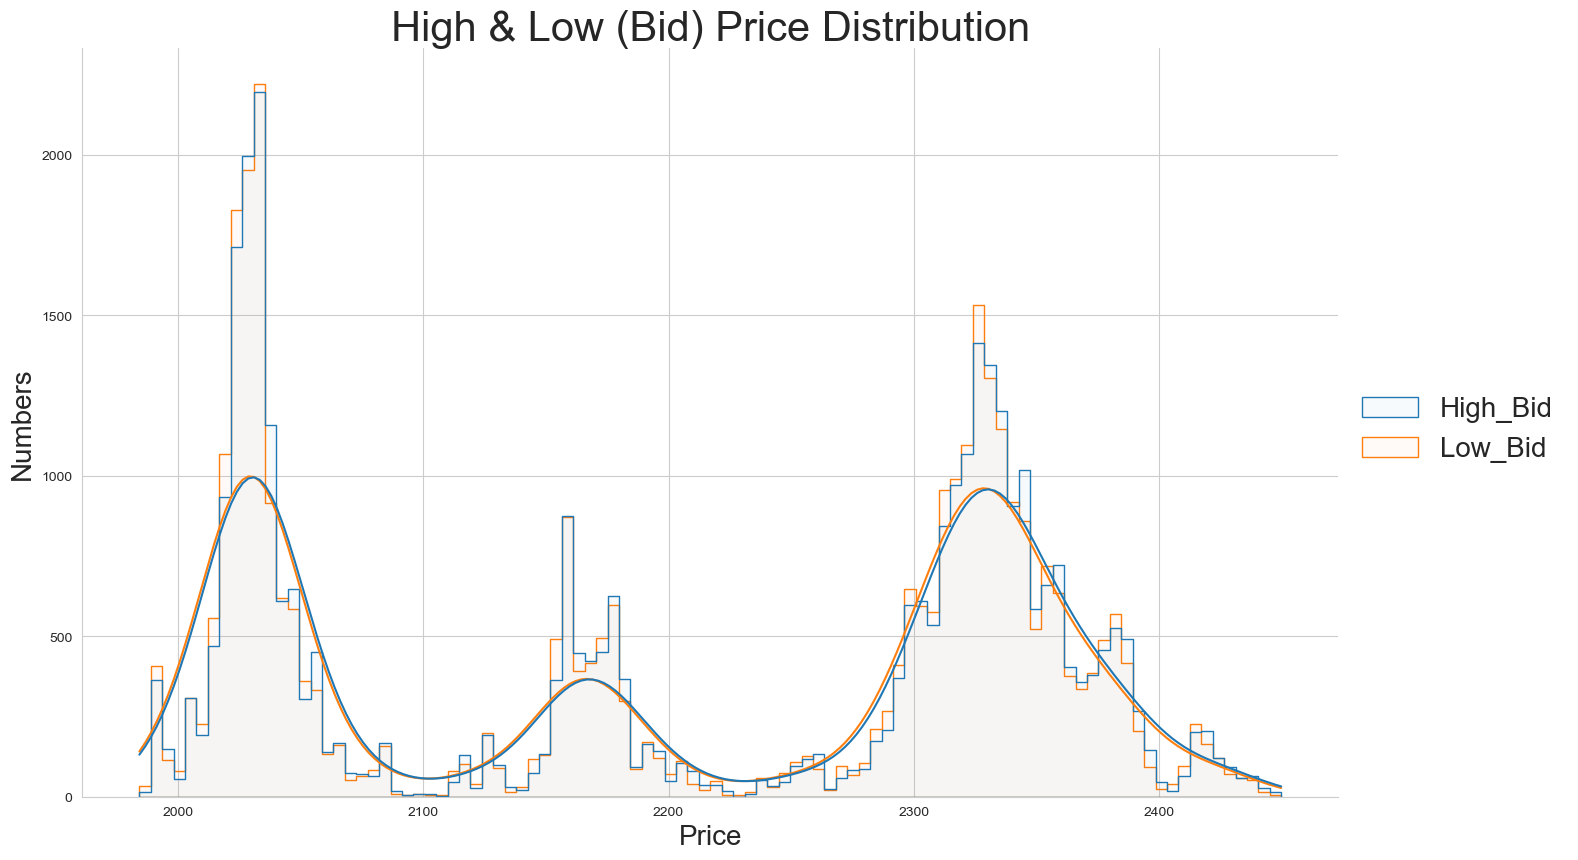

In [40]:
fig = plt.figure(figsize=(9, 4))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data[['High_Bid', 'Low_Bid']],
            height=8,
            aspect=1.7,
            #hue="species",
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price', size= 20)
#plt.ylabel('count (%)')
plt.ylabel('Numbers', size= 20)
plt.show();

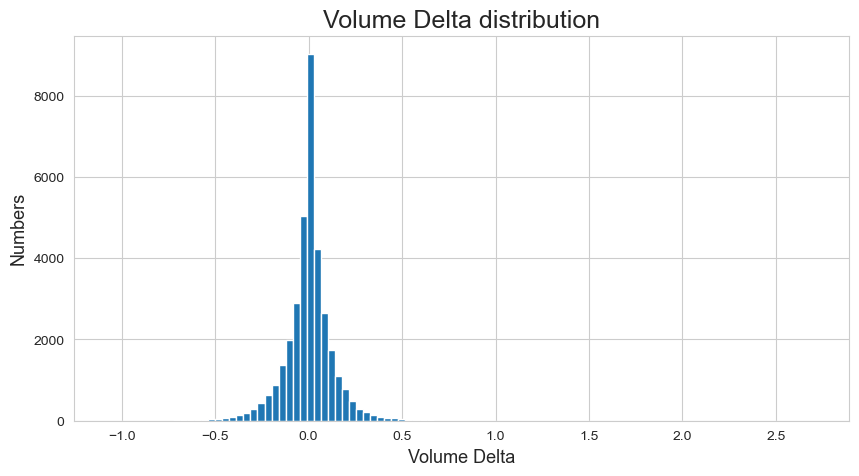

In [41]:
plt.figure(num=1,figsize=(10,5))
plt.hist(data['Volume_Delta'],bins=100)
plt.title('Volume Delta distribution',size=18)
plt.ylabel('Numbers',size=13)
plt.xlabel('Volume Delta',size=13)
plt.show();

In [42]:
# Distribution has mostly positive values
# So Volume_Ask is usually greater than Volume_Bid,
# This corresponds to the upward trend in the first 6 months of 2024

<html> <h3 style="font-style:italic; color:blue;"> Indicate starts of days and weeks </h3> </html>

_______________________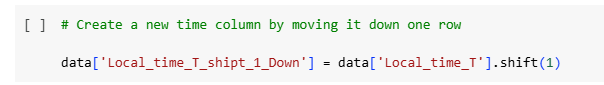

In [43]:
data['Local_time_T_shipt_1_Down'] = data['Local_time_T'].shift(1)

In [44]:
#

______________________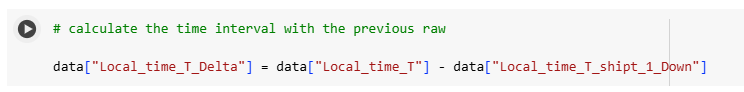

In [45]:
data['Local_time_T_Delta'] = data['Local_time_T'] - data['Local_time_T_shipt_1_Down']

In [46]:
#

________________________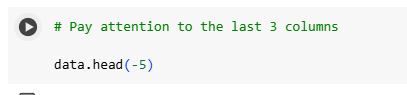

In [47]:
data.head(-5)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,NaT
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,2024-01-01 23:05:00+00:00,2024-01-01 23:00:00+00:00,0 days 00:05:00
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,2024-01-01 23:10:00+00:00,2024-01-01 23:05:00+00:00,0 days 00:05:00
3,2065.715,2066.075,2065.055,2065.585,0.04386,2066.105,2066.525,2065.415,2065.986,0.03201,-0.01185,0.01185,0.390,0.450,0.360,0.401,2024-01-01 23:15:00+00:00,2024-01-01 23:10:00+00:00,0 days 00:05:00
4,2065.585,2065.815,2065.295,2065.555,0.03171,2065.992,2066.242,2065.645,2065.855,0.03309,0.00138,0.00138,0.407,0.427,0.350,0.300,2024-01-01 23:20:00+00:00,2024-01-01 23:15:00+00:00,0 days 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35222,2324.145,2325.445,2324.145,2325.395,0.04935,2324.635,2325.865,2324.635,2325.835,0.05331,0.00396,0.00396,0.490,0.420,0.490,0.440,2024-06-30 23:10:00+00:00,2024-06-30 23:05:00+00:00,0 days 00:05:00
35223,2325.395,2325.465,2324.955,2325.005,0.04422,2325.815,2325.905,2325.355,2325.425,0.02031,-0.02391,0.02391,0.420,0.440,0.400,0.420,2024-06-30 23:15:00+00:00,2024-06-30 23:10:00+00:00,0 days 00:05:00
35224,2324.945,2325.135,2324.655,2325.005,0.01317,2325.355,2325.525,2325.095,2325.415,0.01059,-0.00258,0.00258,0.410,0.390,0.440,0.410,2024-06-30 23:20:00+00:00,2024-06-30 23:15:00+00:00,0 days 00:05:00
35225,2324.975,2325.115,2324.835,2325.055,0.01080,2325.385,2325.525,2325.245,2325.475,0.00846,-0.00234,0.00234,0.410,0.410,0.410,0.420,2024-06-30 23:25:00+00:00,2024-06-30 23:20:00+00:00,0 days 00:05:00


In [48]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4>








In [49]:
# The start of the year is the start of a week
# Therefore, we change the time interval to 2 days (the duration of the weekend).

data['Local_time_T_Delta'].iloc[0] = "2 days 01:01:00"
data['Local_time_T_Delta'].iloc[0]

C:\Users\aazhm\AppData\Local\Temp\ipykernel_18552\1003821487.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Local_time_T_Delta'].iloc[0] = "2 days 01:01:00"
C:\Users\aazhm\AppData\Local\Temp\ipykernel_18552\1003821487.py:4: Settin

Timedelta('2 days 01:01:00')

In [50]:
# find intervals which are longer than 5 minutes
# create a new DataFrame with the beginning of the new days

new_day = data[['Local_time_T_Delta']][data["Local_time_T_Delta"] > '0 days 00:05:00']
new_day['Local_time_T_Delta'].value_counts(sort=False)

Local_time_T_Delta
2 days 01:01:00     1
0 days 01:05:00    98
2 days 01:05:00    24
0 days 03:35:00     4
2 days 00:05:00     1
3 days 01:05:00     1
Name: count, dtype: int64

In [51]:
# We found the duration of night intervals when there is no trading in Gold.
# Total such intervals - 129, which is equal to the number of trading days during 6 first months of 2024

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [52]:
# find intervals which are longer than 1 day
# create a new DataFrame with the beginning of the new weeks

new_week = data[['Local_time_T_Delta']][data['Local_time_T_Delta'] > '1 days 00:00:00']
new_week["Local_time_T_Delta"].value_counts(sort=False)

Local_time_T_Delta
2 days 01:01:00     1
2 days 01:05:00    24
2 days 00:05:00     1
3 days 01:05:00     1
Name: count, dtype: int64

In [53]:
# We found the weekend duration when there is no trading in Gold.
# Total such intervals - 27, which is equal to the number of weekends during 6 first months of 2024

____________________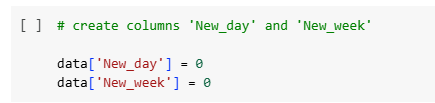

In [54]:
data['New_day'] = 0
data['New_week'] = 0


In [55]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [56]:
# Fill in "1" when the new day starts

data.loc[data["Local_time_T_Delta"] > '0 days 00:05:00', 'New_day'] = 1

__________________________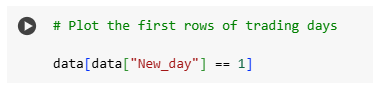

In [57]:
data[data['New_day'] == 1]

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,...,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,2 days 01:01:00,1,0
276,2058.018,2059.134,2058.018,2058.758,0.04366,2059.772,2059.882,2058.952,2059.292,0.03770,...,0.00596,1.754,0.748,0.934,0.534,2024-01-02 23:00:00+00:00,2024-01-02 21:55:00+00:00,0 days 01:05:00,1,0
552,2041.895,2042.425,2041.398,2042.044,0.09643,2042.452,2043.075,2042.015,2042.532,0.10547,...,0.00904,0.557,0.650,0.617,0.488,2024-01-03 23:00:00+00:00,2024-01-03 21:55:00+00:00,0 days 01:05:00,1,0
828,2043.218,2043.685,2042.774,2042.864,0.03565,2044.812,2045.092,2043.302,2043.302,0.02107,...,0.01458,1.594,1.407,0.528,0.438,2024-01-04 23:00:00+00:00,2024-01-04 21:55:00+00:00,0 days 01:05:00,1,0
1104,2044.385,2045.005,2042.825,2044.494,0.16514,2046.355,2046.445,2043.702,2044.966,0.13458,...,0.03056,1.970,1.440,0.877,0.472,2024-01-07 23:00:00+00:00,2024-01-05 21:55:00+00:00,2 days 01:05:00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34104,2333.205,2334.395,2333.205,2333.748,0.07701,2335.000,2335.000,2333.975,2334.245,0.03176,...,0.04525,1.795,0.605,0.770,0.497,2024-06-24 22:00:00+00:00,2024-06-24 20:55:00+00:00,0 days 01:05:00,1,0
34380,2319.575,2319.935,2318.705,2319.925,0.04851,2320.165,2320.655,2319.365,2320.375,0.06285,...,0.01434,0.590,0.720,0.660,0.450,2024-06-25 22:00:00+00:00,2024-06-25 20:55:00+00:00,0 days 01:05:00,1,0
34656,2298.098,2299.055,2297.898,2298.694,0.07182,2299.492,2299.725,2298.736,2299.216,0.07026,...,0.00156,1.394,0.670,0.838,0.522,2024-06-26 22:00:00+00:00,2024-06-26 20:55:00+00:00,0 days 01:05:00,1,0
34932,2327.108,2327.915,2326.875,2326.905,0.02414,2328.992,2328.992,2327.295,2327.315,0.04502,...,0.02088,1.884,1.077,0.420,0.410,2024-06-27 22:00:00+00:00,2024-06-27 20:55:00+00:00,0 days 01:05:00,1,0


In [58]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [59]:
# Fill in "1" when the new week starts

data.loc[data["Local_time_T_Delta"] > '1 days 00:00:00', 'New_week'] = 1

____________________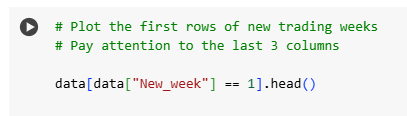

In [60]:
data[data['New_week'] == 1].head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,...,0.00169,1.964,0.880,1.670,0.472,2024-01-01 23:00:00+00:00,NaT,2 days 01:01:00,1,1
1104,2044.385,2045.005,2042.825,2044.494,0.16514,2046.355,2046.445,2043.702,2044.966,0.13458,...,0.03056,1.970,1.440,0.877,0.472,2024-01-07 23:00:00+00:00,2024-01-05 21:55:00+00:00,2 days 01:05:00,1,1
2484,2048.498,2048.598,2046.698,2047.705,0.22412,2050.302,2050.302,2047.302,2048.216,0.21842,...,0.00570,1.804,1.704,0.604,0.511,2024-01-14 23:00:00+00:00,2024-01-12 21:55:00+00:00,2 days 01:05:00,1,1
3834,2029.715,2029.715,2027.915,2028.505,0.12920,2030.305,2030.365,2028.502,2029.042,0.12594,...,0.00326,0.590,0.650,0.587,0.537,2024-01-21 23:00:00+00:00,2024-01-19 21:55:00+00:00,2 days 01:05:00,1,1
5214,2024.215,2027.014,2022.854,2023.515,0.25994,2025.245,2027.776,2023.545,2024.145,0.27963,...,0.01969,1.030,0.762,0.691,0.630,2024-01-28 23:00:00+00:00,2024-01-26 21:55:00+00:00,2 days 01:05:00,1,1


In [61]:
#

______________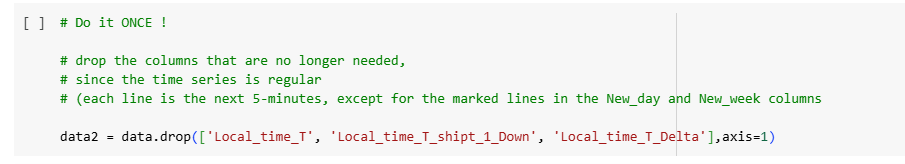

In [62]:
data2 = data.drop(['Local_time_T', 'Local_time_T_shipt_1_Down', 'Local_time_T_Delta'], axis = 1)

In [63]:
#

_____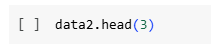

In [64]:
data2.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week
0,2062.598,2066.595,2062.405,2065.214,0.12012,2064.562,2067.475,2064.075,2065.686,0.11843,-0.00169,0.00169,1.964,0.880,1.670,0.472,1,1
1,2065.185,2065.194,2063.851,2064.455,0.06508,2065.616,2065.839,2064.476,2064.902,0.06906,0.00398,0.00398,0.431,0.645,0.625,0.447,0,0
2,2064.424,2066.365,2064.395,2065.734,0.03945,2064.902,2066.825,2064.752,2066.105,0.04203,0.00258,0.00258,0.478,0.460,0.357,0.371,0,0


In [65]:
#

____________________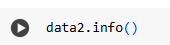

In [66]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float64
 1   High_Bid          35232 non-null  float64
 2   Low_Bid           35232 non-null  float64
 3   Close_Bid         35232 non-null  float64
 4   Volume_Bid        35232 non-null  float64
 5   Open_Ask          35232 non-null  float64
 6   High_Ask          35232 non-null  float64
 7   Low_Ask           35232 non-null  float64
 8   Close_Ask         35232 non-null  float64
 9   Volume_Ask        35232 non-null  float64
 10  Volume_Delta      35232 non-null  float64
 11  Volume_Delta_abs  35232 non-null  float64
 12  Open_Delta        35232 non-null  float64
 13  High_Delta        35232 non-null  float64
 14  Low_Delta         35232 non-null  float64
 15  Close_Delta       35232 non-null  float64
 16  New_day           35232 non-null  int64 

In [67]:
#

__________________________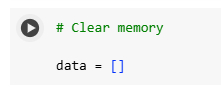

In [68]:
data = []

In [69]:
#

## We will look for rows with potential take-profit = $10


- create 'High_Bid' and 'Low_Ask' 4 hours ahead
- that is, the maximum holding of a position is no more than 4 hours
- 4 hours is 48 of 5-minute intervals


______________________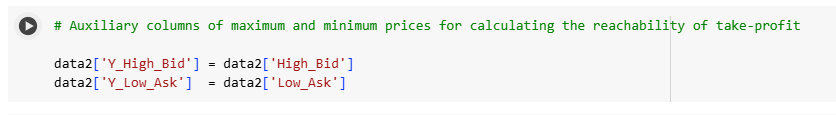

In [70]:
data2['Y_High_Bid'] = data2['High_Bid']
data2['Y_Low_Ask'] = data2['Low_Ask']

In [71]:
#

___________________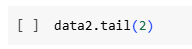

In [72]:
data2.tail(2)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
35230,2325.515,2325.525,2325.125,2325.385,0.09813,2325.945,2325.945,2325.555,2325.795,0.02880,-0.06933,0.06933,0.430,0.420,0.430,0.41,0,0,2325.525,2325.555
35231,2325.438,2325.438,2324.625,2324.825,0.07851,2325.825,2325.835,2325.066,2325.245,0.07257,-0.00594,0.00594,0.387,0.397,0.441,0.42,0,0,2325.438,2325.066


In [73]:
#

<html> <h3 style="font-style:italic; color:blue;"> Data Normalisation </h3> </html>

In [74]:
# We do price normalisation simply by dividing all prices by 1000 (for Gold)
# It is not essential that the normalised prices were in the range between [0,1]
# It is more important that the variables were approximately of the same order

In [75]:
# Only applicable to Volumes and Deltas:

# normalisation
# data=(data-data.min())/(data.max()-data.min())

##### Find Max and Min for Prices, Volumes and Deltas

In [76]:
# Max price is Max High_Ask
# Min price is Min Low_Bid

# Max Volume = Max{Volume_Bid, Volume_Ask}
# Min Volume = 0

# Max_Delta = Max{Open_Delta, High_Delta, Low_Delta, Close_Delta}
# Min_Delta = Min{Open_Delta, High_Delta, Low_Delta, Close_Delta}

_______________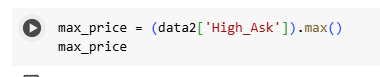

In [77]:
max_price = (data2['High_Ask']).max()
max_price

2450.325

In [78]:
#

__________________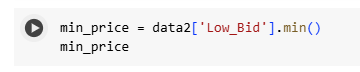

In [79]:
min_price = (data2['Low_Bid']).min()
min_price

1984.088

In [80]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4> </html>

In [81]:
max_volume = max(max(data2['Volume_Bid']), max(data2['Volume_Ask']))
max_volume

2.84268

In [82]:
max_Delta = max(max(data2['Open_Delta']), max(data2['High_Delta']), max(data2['Low_Delta']), max(data2['Close_Delta']))
max_Delta

5.9809999999999945

____________________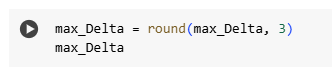

In [83]:
max_Delta = round(max_Delta, 3)
max_Delta

5.981

In [84]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [85]:
min_Delta = min(min(data2['Open_Delta']), min(data2['High_Delta']), min(data2['Low_Delta']), min(data2['Close_Delta']))
min_Delta

0.0010000000002037268

______________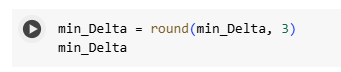

In [86]:
min_Delta = round(min_Delta, 3)
min_Delta

0.001

In [87]:
#

______________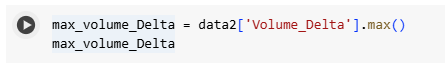

In [88]:
max_volume_Delta = data2['Volume_Delta'].max()
max_volume_Delta

2.70359

In [89]:
#

__________________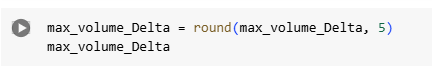

In [90]:
max_volume_Delta = round(max_volume_Delta, 5)
max_volume_Delta

2.70359

In [91]:
#

______________________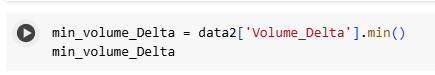

In [92]:
min_volume_Delta = data2['Volume_Delta'].min()
min_volume_Delta

-1.0644

In [93]:
#

_________________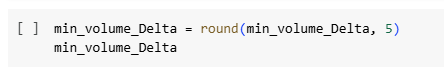

In [94]:
min_volume_Delta = round(min_volume_Delta, 5)
min_volume_Delta

-1.0644

In [95]:
#

_________________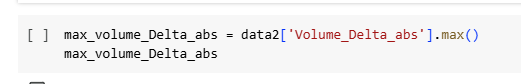

In [96]:
max_volume_Delta_abs = data2['Volume_Delta_abs'].max()
max_volume_Delta_abs

2.70359

__________________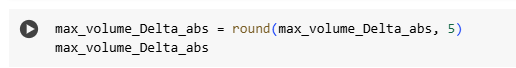

In [97]:
max_volume_Delta_abs = round(max_volume_Delta_abs, 5)
max_volume_Delta_abs

2.70359

In [98]:
#

__________________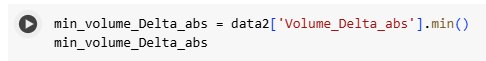

In [99]:
min_volume_Delta_abs = data2['Volume_Delta_abs'].min()
min_volume_Delta_abs

0.0

In [100]:
#

In [101]:
# min_volume_Delta_abs = 0
# Therefore, the normalization formula for volume_Delta_abs is simplified

#### Normalise
Run each cell only one time !

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 5 cells with code using 'Ctrl' + 'Enter' </h4> </html>

In [102]:
# Цены просто делим на 100

data2['Open_Bid']   = data2['Open_Bid']   / 1000
data2['High_Bid']   = data2['High_Bid']   / 1000
data2['Low_Bid']    = data2['Low_Bid']    / 1000
data2['Close_Bid']  = data2['Close_Bid']  / 1000

data2['Open_Ask']   = data2['Open_Ask']   / 1000
data2['High_Ask']   = data2['High_Ask']   / 1000
data2['Low_Ask']    = data2['Low_Ask']    / 1000
data2['Close_Ask']  = data2['Close_Ask']  / 1000

data2['Y_High_Bid'] = data2['Y_High_Bid'] / 1000
data2['Y_Low_Ask']  = data2['Y_Low_Ask']  / 1000



In [103]:
data2['Volume_Ask']  = data2['Volume_Ask'] / max_volume
data2['Volume_Bid']  = data2['Volume_Bid'] / max_volume

In [104]:
data2['Volume_Delta'] = ( data2['Volume_Delta'] - min_volume_Delta ) / (max_volume_Delta-min_volume_Delta)

In [105]:
data2['Volume_Delta_abs']  = data2['Volume_Delta_abs'] / max_volume_Delta_abs

In [106]:
# For the price deltas, the minimum difference is more interesting, therefore we apply inverse normalisation
# data= 1 - (data - data.min()) / (data.max() - data.min()) = (data.max() - data) / (data.max() - data.min())


In [107]:
data2['Open_Delta']  = ( max_Delta - data2['Open_Delta'] )  / (max_Delta-min_Delta)
data2['High_Delta']  = ( max_Delta - data2['High_Delta'] )  / (max_Delta-min_Delta)
data2['Low_Delta']   = ( max_Delta - data2['Low_Delta'] )   / (max_Delta-min_Delta)
data2['Close_Delta'] = ( max_Delta - data2['Close_Delta'] ) / (max_Delta-min_Delta)

________________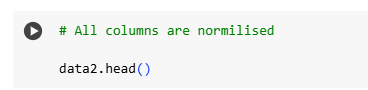

In [108]:
data2.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
0,2.062598,2.066595,2.062405,2.065214,0.042256,2.064562,2.067475,2.064075,2.065686,0.041661,0.282036,0.000625,0.671739,0.853010,0.720903,0.921237,1,1,2.066595,2.064075
1,2.065185,2.065194,2.063851,2.064455,0.022894,2.065616,2.065839,2.064476,2.064902,0.024294,0.283541,0.001472,0.928094,0.892308,0.895652,0.925418,0,0,2.065194,2.064476
2,2.064424,2.066365,2.064395,2.065734,0.013878,2.064902,2.066825,2.064752,2.066105,0.014785,0.283170,0.000954,0.920234,0.923244,0.940468,0.938127,0,0,2.066365,2.064752
3,2.065715,2.066075,2.065055,2.065585,0.015429,2.066105,2.066525,2.065415,2.065986,0.011261,0.279340,0.004383,0.934950,0.924916,0.939967,0.933110,0,0,2.066075,2.065415
4,2.065585,2.065815,2.065295,2.065555,0.011155,2.065992,2.066242,2.065645,2.065855,0.011640,0.282851,0.000510,0.932107,0.928763,0.941639,0.950000,0,0,2.065815,2.065645


In [109]:
#

__________________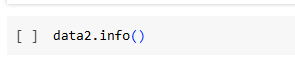

In [110]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float64
 1   High_Bid          35232 non-null  float64
 2   Low_Bid           35232 non-null  float64
 3   Close_Bid         35232 non-null  float64
 4   Volume_Bid        35232 non-null  float64
 5   Open_Ask          35232 non-null  float64
 6   High_Ask          35232 non-null  float64
 7   Low_Ask           35232 non-null  float64
 8   Close_Ask         35232 non-null  float64
 9   Volume_Ask        35232 non-null  float64
 10  Volume_Delta      35232 non-null  float64
 11  Volume_Delta_abs  35232 non-null  float64
 12  Open_Delta        35232 non-null  float64
 13  High_Delta        35232 non-null  float64
 14  Low_Delta         35232 non-null  float64
 15  Close_Delta       35232 non-null  float64
 16  New_day           35232 non-null  int64 

In [111]:
#

### Hint:

You can copy many blocks of text in the cells from the previous 2 weeks of practice sessions.
Some are easy enough to copy, some need to be slightly modified. In any case, this can speed up your code creation.

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [112]:
# Reducing memory size

columns_float =['Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
                'Volume_Delta', 'Volume_Delta_abs',
                'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta',
                'Y_High_Bid', 'Y_Low_Ask']

columns_integer =['New_day', 'New_week']



__________________________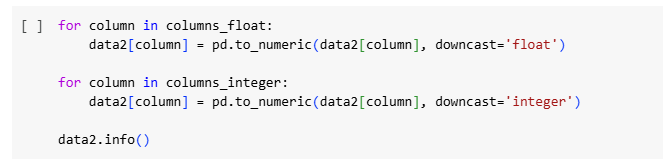

In [113]:
for column in columns_float:
  data2[column] = pd.to_numeric(data2[column], downcast='float')
for column in columns_integer:
  data2[column] = pd.to_numeric(data2[column], downcast='integer')
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float32
 1   High_Bid          35232 non-null  float32
 2   Low_Bid           35232 non-null  float32
 3   Close_Bid         35232 non-null  float32
 4   Volume_Bid        35232 non-null  float32
 5   Open_Ask          35232 non-null  float32
 6   High_Ask          35232 non-null  float32
 7   Low_Ask           35232 non-null  float32
 8   Close_Ask         35232 non-null  float32
 9   Volume_Ask        35232 non-null  float32
 10  Volume_Delta      35232 non-null  float32
 11  Volume_Delta_abs  35232 non-null  float32
 12  Open_Delta        35232 non-null  float32
 13  High_Delta        35232 non-null  float32
 14  Low_Delta         35232 non-null  float32
 15  Close_Delta       35232 non-null  float32
 16  New_day           35232 non-null  int8  

In [114]:
#

We reduced the data memory by more than 2 times: from 5.4 MB to 2.5 MB

____________________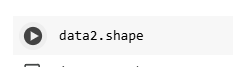

In [115]:
data2.shape

(35232, 20)

In [116]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

<Figure size 1200x500 with 0 Axes>

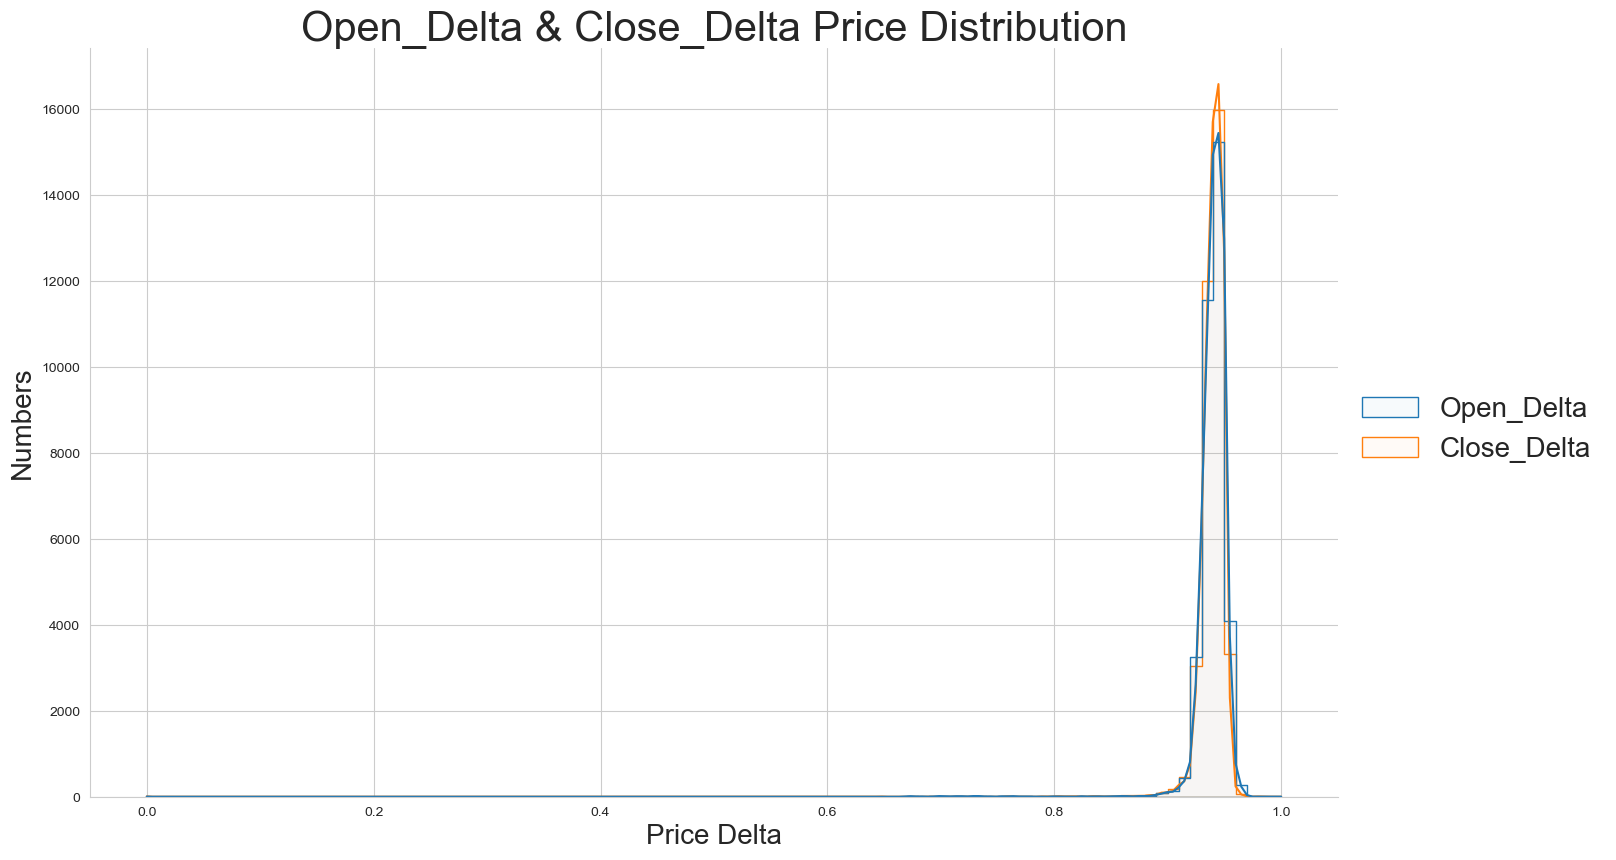

In [117]:
# inverse normalisation of price deltas, the minimum difference is more interesting

fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data2[['Open_Delta', 'Close_Delta']],
            height=8,
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('Open_Delta & Close_Delta Price Distribution')
plt.xlabel('Price Delta', size= 20)
plt.ylabel('Numbers', size= 20)
plt.show();

### Date transformation


In [118]:
# We will predict Wait-Attention modes
# Since we have a 5-minute dataset, Then we will shift MiN & MAX prices by 48 rows, which is 4 hours forward

_____________________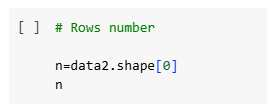

In [119]:
n = data2.shape[0]
n

35232

In [120]:
#

___________________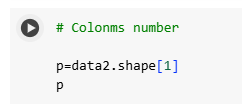

In [121]:
p = data2.shape[1]
p

20

In [122]:
#

_____________________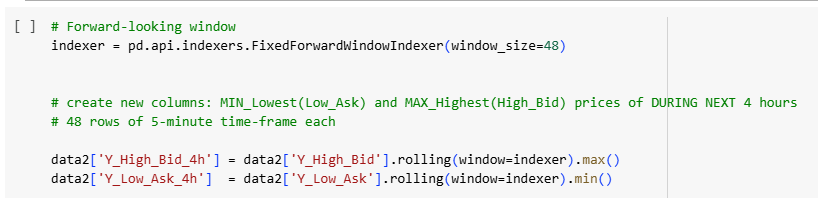

In [123]:
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=48)


data2['Y_High_Bid_4h'] = data2['Y_High_Bid'].rolling(window = indexer).max()
data2['Y_Low_Ask_4h'] = data2['Y_Low_Ask'].rolling(window = indexer).min()

________________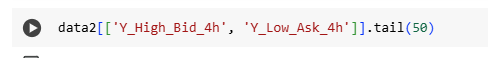

In [124]:
data2[['Y_High_Bid_4h', 'Y_Low_Ask_4h']].tail(50)

,Y_High_Bid_4h,Y_Low_Ask_4h
35182,2.326775,2.323125
35183,2.326775,2.323125
35184,2.326775,2.323125
35185,NaN,NaN
35186,NaN,NaN
35187,NaN,NaN
35188,NaN,NaN
35189,NaN,NaN
35190,NaN,NaN
35191,NaN,NaN


_________________________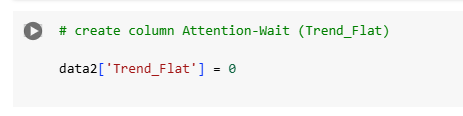

In [126]:
data2['Trend_Flat'] = 0

In [127]:
#


<html> <h4 style="font-style:italic; color:blue;"> Just run the 2 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [128]:
# Fill in "1s" If the movement (in any direction) within 4 hours is more than $10 (0.01 after the normalisation)

data2.loc[ (data2["Y_High_Bid_4h"] - data2["Close_Ask"]) >= 0.01, 'Trend_Flat'] = 1
print( data2['Trend_Flat'].sum() )

data2.loc[ (data2["Close_Bid"] - data2["Y_Low_Ask_4h"]) >= 0.01, 'Trend_Flat'] = 1
print( data2['Trend_Flat'].sum() )

5767
10758


In [129]:
print(((data2["Y_High_Bid_4h"] - data2["Close_Ask"])>= 0.01).sum())
print(((data2["Close_Bid"] - data2["Y_Low_Ask_4h"])>= 0.01).sum())

5767
5450


In [130]:
# (5767+5450) = 11217
# 11217-10758 = 459       # rows after which the price moved in both directions by $10 or more

__________________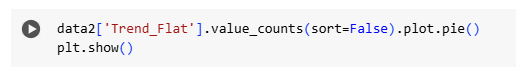

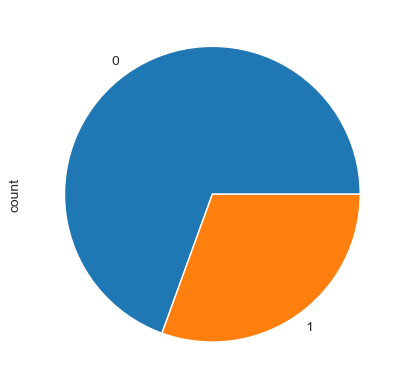

In [131]:
data2['Trend_Flat'].value_counts(sort=False).plot.pie()
plt.show()

In [132]:
#

In [133]:
# The dataset is unbalanced

____________________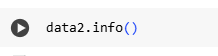

In [134]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35232 non-null  float32
 1   High_Bid          35232 non-null  float32
 2   Low_Bid           35232 non-null  float32
 3   Close_Bid         35232 non-null  float32
 4   Volume_Bid        35232 non-null  float32
 5   Open_Ask          35232 non-null  float32
 6   High_Ask          35232 non-null  float32
 7   Low_Ask           35232 non-null  float32
 8   Close_Ask         35232 non-null  float32
 9   Volume_Ask        35232 non-null  float32
 10  Volume_Delta      35232 non-null  float32
 11  Volume_Delta_abs  35232 non-null  float32
 12  Open_Delta        35232 non-null  float32
 13  High_Delta        35232 non-null  float32
 14  Low_Delta         35232 non-null  float32
 15  Close_Delta       35232 non-null  float32
 16  New_day           35232 non-null  int8  

In [135]:
#

_____________________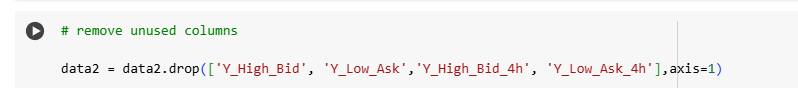

In [136]:
data2 = data2.drop(['Y_High_Bid', 'Y_Low_Ask', 'Y_High_Bid_4h', 'Y_Low_Ask_4h'], axis = 1)

In [137]:
#

__________________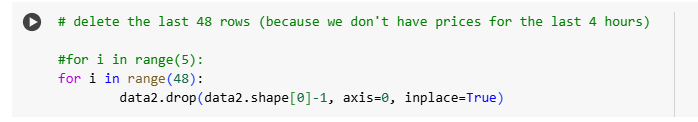

In [138]:
for i in range(48):
  data2.drop(data2.shape[0]-1, axis = 0, inplace = True)

In [139]:
#

____________________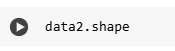

In [140]:
data2.shape

(35184, 19)

In [141]:
#

_______________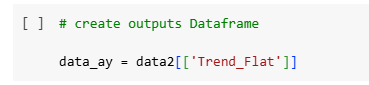

In [142]:
data_ay = data2[['Trend_Flat']]

In [143]:
#

__________________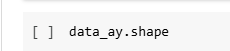

In [144]:
data_ay.shape

(35184, 1)

In [145]:
#

_________________________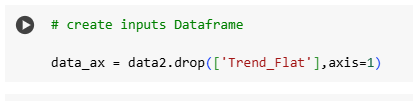

In [146]:
data_ax = data2.drop(['Trend_Flat'], axis = 1)

In [147]:
#

______________________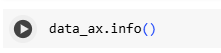

In [148]:
data_ax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35184 entries, 0 to 35183
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          35184 non-null  float32
 1   High_Bid          35184 non-null  float32
 2   Low_Bid           35184 non-null  float32
 3   Close_Bid         35184 non-null  float32
 4   Volume_Bid        35184 non-null  float32
 5   Open_Ask          35184 non-null  float32
 6   High_Ask          35184 non-null  float32
 7   Low_Ask           35184 non-null  float32
 8   Close_Ask         35184 non-null  float32
 9   Volume_Ask        35184 non-null  float32
 10  Volume_Delta      35184 non-null  float32
 11  Volume_Delta_abs  35184 non-null  float32
 12  Open_Delta        35184 non-null  float32
 13  High_Delta        35184 non-null  float32
 14  Low_Delta         35184 non-null  float32
 15  Close_Delta       35184 non-null  float32
 16  New_day           35184 non-null  int8  

In [149]:
#

____________________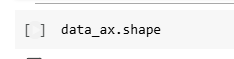

In [150]:
data_ax.shape

(35184, 18)

In [151]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the 2 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [152]:
# Create inputs Numpy

data_a = np.array(data_ax)

with np.printoptions(precision=4):
    print("data_a:")
    print(data_a[:2,:])
    print('\n')
    print(data_a[-2:,:])

print("numpy size: = ", data_a.shape)
print("type: ", data_a.dtype)


data_a:
[[2.0626e+00 2.0666e+00 2.0624e+00 2.0652e+00 4.2256e-02 2.0646e+00
  2.0675e+00 2.0641e+00 2.0657e+00 4.1661e-02 2.8204e-01 6.2509e-04
  6.7174e-01 8.5301e-01 7.2090e-01 9.2124e-01 1.0000e+00 1.0000e+00]
 [2.0652e+00 2.0652e+00 2.0639e+00 2.0645e+00 2.2894e-02 2.0656e+00
  2.0658e+00 2.0645e+00 2.0649e+00 2.4294e-02 2.8354e-01 1.4721e-03
  9.2809e-01 8.9231e-01 8.9565e-01 9.2542e-01 0.0000e+00 0.0000e+00]]


[[2.3258 2.326  2.3256 2.3259 0.0276 2.3261 2.3263 2.3259 2.3262 0.0538
  0.3023 0.0276 0.9393 0.9455 0.9472 0.9393 0.     0.    ]
 [2.3259 2.326  2.3252 2.3257 0.0503 2.3262 2.3264 2.3256 2.326  0.0558
  0.2866 0.0058 0.9455 0.9393 0.94   0.9393 0.     0.    ]]
numpy size: =  (35184, 18)
type:  float32


In [153]:
# Create outputs Numpy

data_y = np.array(data_ay)

print("data_a:")
print(data_y[:3,:])
print('\n')
print(data_y[-3:,:])

print("numpy size: = ", data_y.shape)
print("type: ", data_y.dtype)

data_a:
[[0]
 [0]
 [0]]


[[0]
 [0]
 [0]]
numpy size: =  (35184, 1)
type:  int64


____________________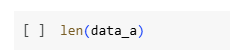

In [154]:
len(data_a)

35184

In [155]:
#

#### Create the 3D inputs tensor, and 2D outputs matrix

In [156]:
# Analysis of the entire dataset would take a long time,
# so, please reduce the dataset by about 3 times to 12000 rows

# n_small = 12000 rows (5-minutes), which is around 2 months.

In [157]:
# We need a three-dimensional data tensor: [(n_small-N ), N, 18] and
# one-dimensional array of answers [(n_small-N ), 1] with the High and Low prices DURING the next 5 minutes

# where N=50 is the number of minutes for analysis at each step; those are looking backwards

# Therefore, we need:
# three-dimensional data tensor of sliced graphs [(n_small - N - 5), N, 18] and
# two-dimensional matrix of answers Y[(n_small - N - 5), 2]
# with the Trend-Flat indicator, indicating whether take profit will be reached within 4 hours or not

___________________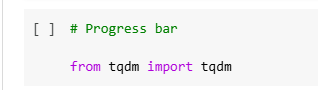

In [158]:
from tqdm import tqdm

In [159]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 4 cells using 'Ctrl' + 'Enter' </h4> </html>

In [160]:
# n_small = len(data_y)

n_small = 12000    # reduce the dataset size

N=50               # sliding window depth

L=n_small-N        # number of sliding window slices
t=data_a.shape[1]  # features number
print('Size of a three-dimensional inputs tensor: ',L,N,t)


Size of a three-dimensional inputs tensor:  11950 50 18


In [161]:
# create imputs zeros 3D tensors with 'float32'

data_b = np.zeros( (L, N, t), dtype= 'float32' )

In [162]:
# create a one-dimensional zeros vector of answers

Y = np.zeros((L, 1), dtype= 'float32')  # We will predict Attention - Wait for signals

In [163]:
# fill the imputs 3D tansor (data_b)
# and the array of answers Y


print('L = n_small - N = ', n_small-N, L)
for k in tqdm(range(L)):
    data_b[k, :, :] = data_a[k:k+N, :]

    Y[k,0] = data_y[k+N-1,0]   # Trend-Flat signal

print(k)                       # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n_small - N =  11950 11950


100%|██████████| 11950/11950 [00:00<00:00, 132384.07it/s]

11949
data_b: 
 [[[2.062598   2.066595   2.062405   ... 0.92123747 1.         1.        ]
  [2.065185   2.065194   2.063851   ... 0.9254181  0.         0.        ]
  [2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  ...
  [2.067375   2.067745   2.067238   ... 0.9438127  0.         0.        ]
  [2.067695   2.067725   2.066445   ... 0.95167226 0.         0.        ]
  [2.066995   2.068605   2.066958   ... 0.95167226 0.         0.        ]]

 [[2.065185   2.065194   2.063851   ... 0.9254181  0.         0.        ]
  [2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  [2.065715   2.066075   2.065055   ... 0.93311036 0.         0.        ]
  ...
  [2.067695   2.067725   2.066445   ... 0.95167226 0.         0.        ]
  [2.066995   2.068605   2.066958   ... 0.95167226 0.         0.        ]
  [2.068455   2.069415   2.068408   ... 0.95167226 0.         0.        ]]

 [[2.064424   2.066365   2.064395   ... 0.9381271  0.         0.        ]
  [2.0

________________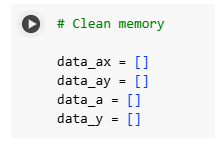

In [164]:
data_ax = []
data_ay = []
data_a = []
data_y = []

In [165]:
#

### Train Test Split
- 90% for training and validation
- 10% for testing

________________________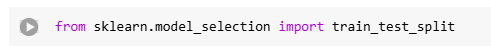

In [166]:
from sklearn.model_selection import train_test_split

In [167]:
#

<html> <h3 style="font-style:bold; color:red;"> !!! Use parameters: shuffle = False, stratify = None

Otherwise, the whole time series will be mixed up!
</h3> </html>

_________________________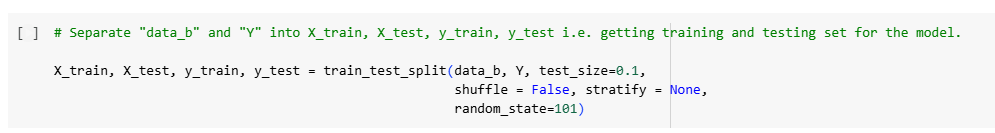

In [168]:
X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.1,
                                                    shuffle = False, stratify=None, random_state=101)

In [169]:
#

___________________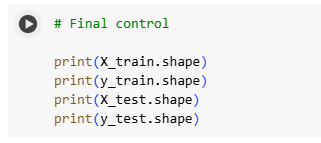

In [170]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10755, 50, 18)
(10755, 1)
(1195, 50, 18)
(1195, 1)


In [171]:
#

#### Balancing Classes in the Dataset

In [172]:
# Use class weights (class_weight) in the fit method to make the model "pay more attention" to the smaller class.

__________________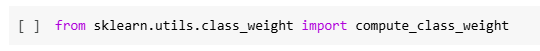

In [173]:
from sklearn.utils.class_weight import compute_class_weight


In [174]:
#

_____________________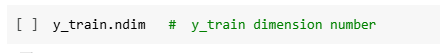

In [175]:
y_train.ndim

2

In [176]:
#

_____________________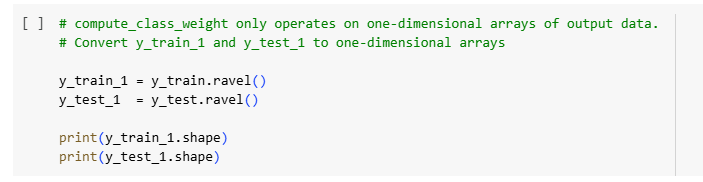

In [177]:
y_train_1 = y_train.ravel()
y_test_1 = y_test.ravel()
print(y_train_1.shape)
print(y_test_1.shape)


(10755,)
(1195,)


In [178]:
#

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [179]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_1), y=y_train_1)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

____________________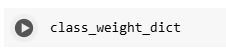

In [180]:
class_weight_dict

{0: 0.5886699507389163, 1: 3.3194444444444446}

In [181]:
#

### Training

#### LSTM

____________________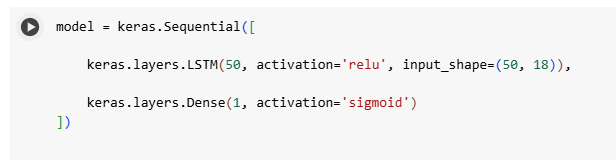

In [182]:
model = keras.Sequential([
    keras.layers.LSTM(50, activation = 'relu', input_shape = (50, 18)),
    keras.layers.Dense(1, activation = 'sigmoid')
])

c:\Users\aazhm\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [183]:
#

________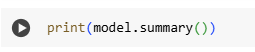

In [184]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,851 (54.11 KB)

 Trainable params: 13,851 (54.11 KB)

 Non-trainable params: 0 (0.00 B)

None


In [185]:
#

_________________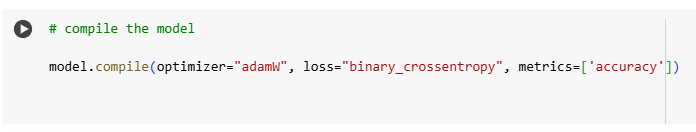

In [186]:
model.compile(optimizer = 'adamW', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [187]:
#


#### Callbacks

________________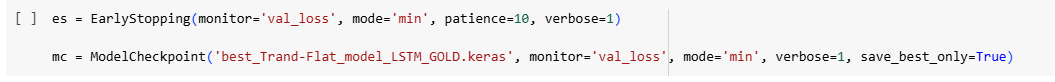

In [188]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
mc = ModelCheckpoint('best_Trand-Flat_model_LSTM_GOLD.keras', monitor = 'val_loss', mode='min', verbose = 1, save_best_only=True)

In [189]:
#

<html> <h4 style="font-style:bold; color:blue;"> If you are using your own laptop without a GPU (Graphics processing unit) and outiside of the Google Colab,

please change the following parameter in the next cell
</h4> </html>

<html> <h4 style="font-style:bold; color:red;">
epochs=10
</h4> </html>


_________________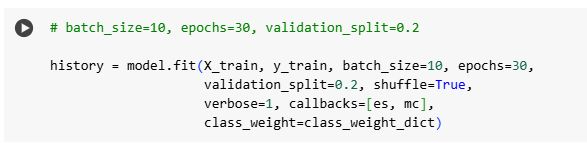

In [190]:
history = model.fit(X_train, y_train, batch_size = 10, epochs = 30,
                    validation_split = 0.2, shuffle = True, verbose = 1, callbacks = [es, mc],
                    class_weight = class_weight_dict)

Epoch 1/30
859/861 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3158 - loss: 0.7295
Epoch 1: val_loss improved from inf to 0.76860, saving model to best_Trand-Flat_model_LSTM_GOLD.keras
861/861 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.3157 - loss: 0.7295 - val_accuracy: 0.0744 - val_loss: 0.7686
Epoch 2/30
861/861 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3540 - loss: 0.7225
Epoch 2: val_loss improved from 0.76860 to 0.57524, saving model to best_Trand-Flat_model_LSTM_GOLD.keras
861/861 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.3540 - loss: 0.7225 - val_accuracy: 0.9107 - val_loss: 0.5752
Epoch 3/30
860/861 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4414 - loss: 0.7108
Epoch 3: val_loss did not improve from 0.57524
861/861 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.4415 - loss: 0.7107 - val_accuracy: 0.8113 - val_loss: 0.6285
Epoch 4/30
859/861 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5509 - loss: 0.6894
Epoch 4: val_loss did not improve from 0

In [191]:
#

_______________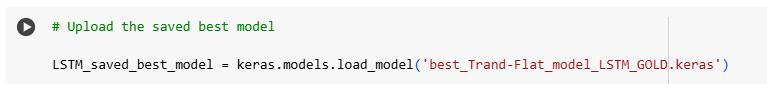

In [192]:
LSTM_saved_best_model = keras.models.load_model('best_Trand-Flat_model_LSTM_GOLD.keras')


In [193]:
#

#### Test

___________________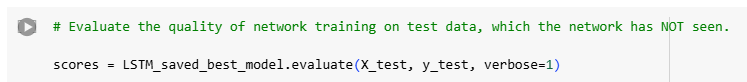

In [194]:
scores = LSTM_saved_best_model.evaluate(X_test, y_test, verbose=0)


In [195]:
#

______________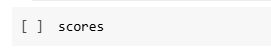

In [196]:
scores

[0.5055680274963379, 0.7456067204475403]

In [197]:
#

### Visualisation

### Hint:

You can copy many blocks of text in the cells from the previous 2 weeks of practice sessions.
Some are easy enough to copy, some need to be slightly modified. In any case, this can speed up your code creation.

#### Loss function graphs during training

______________________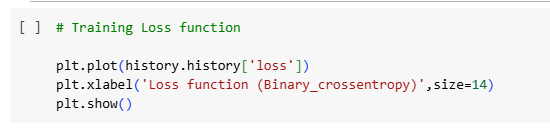

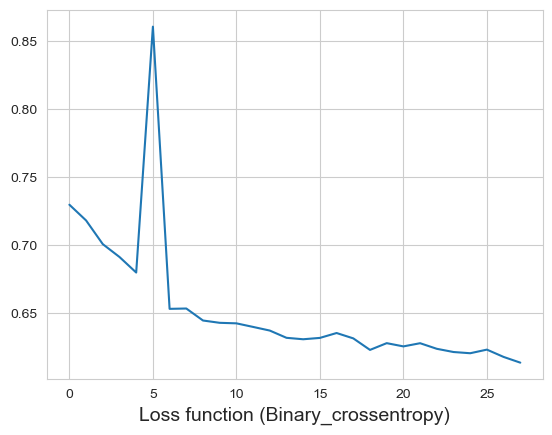

In [198]:
plt.plot(history.history['loss'])
plt.xlabel('Loss function (Binary_crossentropy)', size= 14)
plt.show()

In [199]:
#

__________________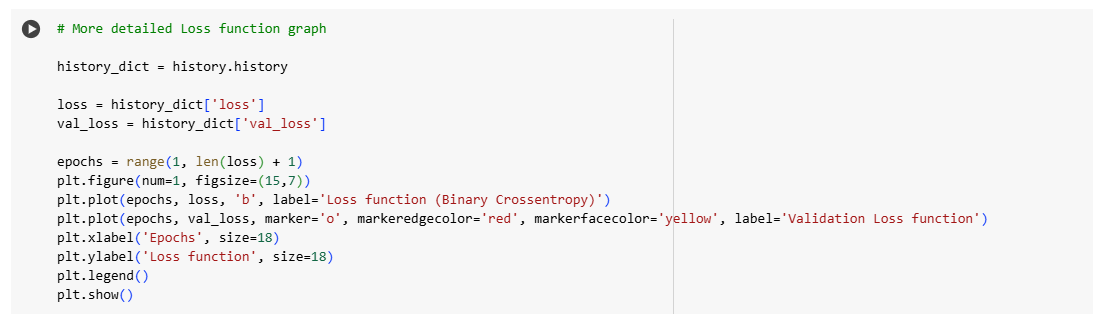

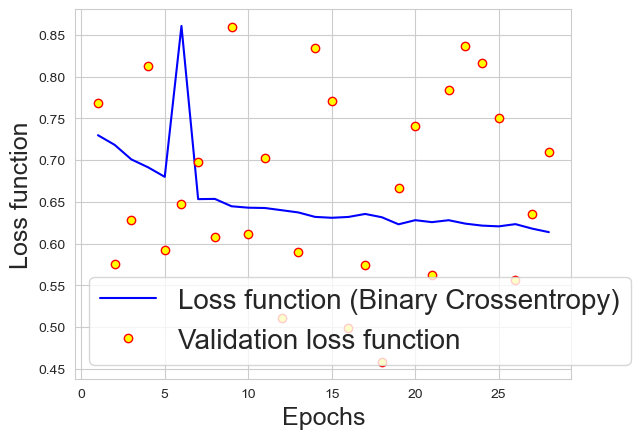

In [200]:
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'b', label='Loss function (Binary Crossentropy)')
plt.plot(epochs, val_loss, 'o', markeredgecolor = 'red', markerfacecolor = 'yellow', label='Validation loss function')
plt.xlabel('Epochs', size = 18)
plt.ylabel('Loss function', size = 18)
plt.legend()
plt.show()

In [201]:
#

____________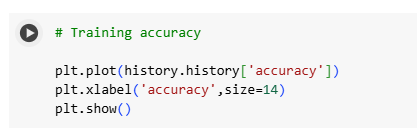

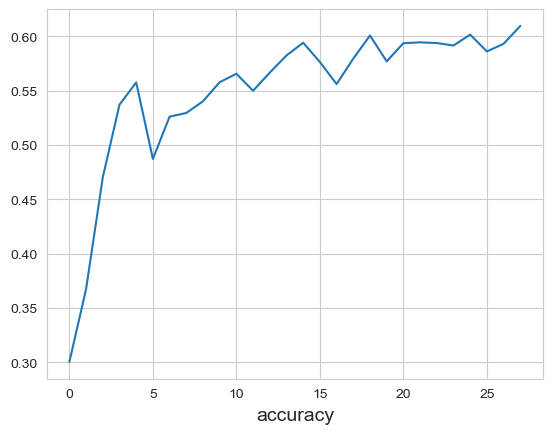

In [202]:
plt.plot(history.history['accuracy'])
plt.xlabel('accuracy', size = 14)
plt.show()

In [203]:
#

____________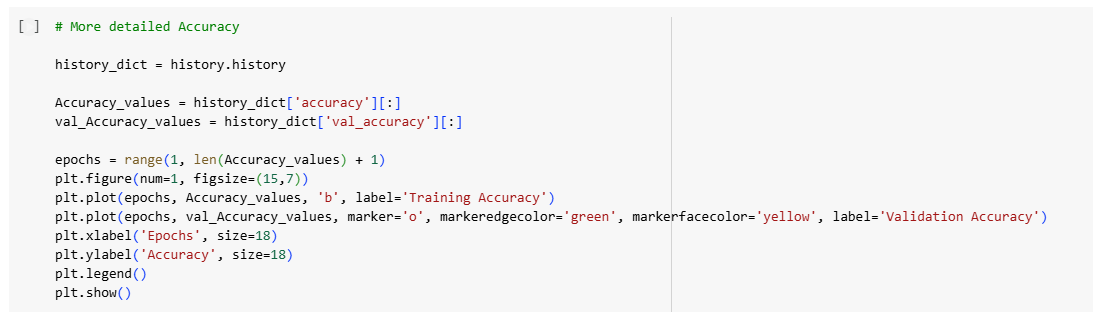

In [260]:
epochs = range(1, len(loss) + 1)
epochs

range(1, 29)

range(1, 29)

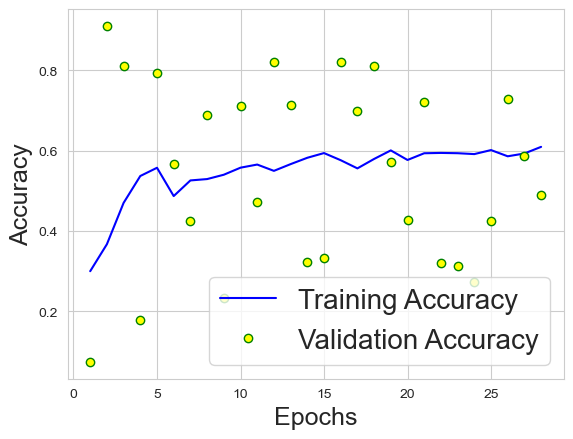

In [251]:
history_dict = history.history
Accuracy_values = history_dict['accuracy'][:]
val_Accuracy_values = history_dict['val_accuracy'][:]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, Accuracy_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_Accuracy_values, 'o', markeredgecolor = 'green', markerfacecolor = 'yellow', label='Validation Accuracy')
plt.xlabel('Epochs', size = 18)
plt.ylabel('Accuracy', size = 18)
plt.legend()
plt.show()

In [205]:
#

_________________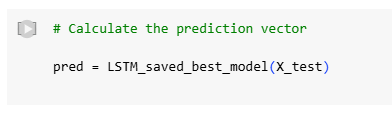

In [206]:
pred = LSTM_saved_best_model(X_test)

In [207]:
#

______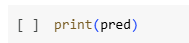

In [208]:
print(pred)

tf.Tensor(
[[0.29955414]
 [0.3255439 ]
 [0.34765258]
 ...
 [0.73332447]
 [0.7757371 ]
 [0.73933595]], shape=(1195, 1), dtype=float32)


In [209]:
#

______________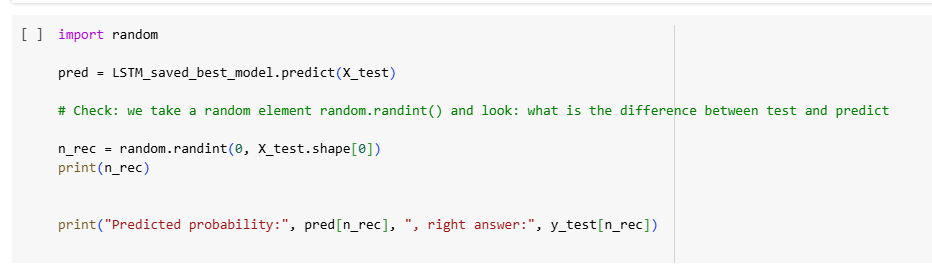

In [210]:
import random
pred = LSTM_saved_best_model(X_test)
n_rec = random.randint(0, X_test.shape[0])
print(n_rec)
print("Predicted probability: ", pred[n_rec], ", right answer", y_test[n_rec])


1133
Predicted probability:  tf.Tensor([0.35821515], shape=(1,), dtype=float32) , right answer [1.]


In [211]:
#

______________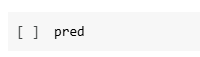

In [212]:
pred

<tf.Tensor: shape=(1195, 1), dtype=float32, numpy=
array([[0.29955414],
       [0.3255439 ],
       [0.34765258],
       ...,
       [0.73332447],
       [0.7757371 ],
       [0.73933595]], dtype=float32)>

In [213]:
#

______________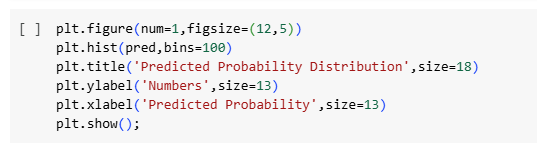

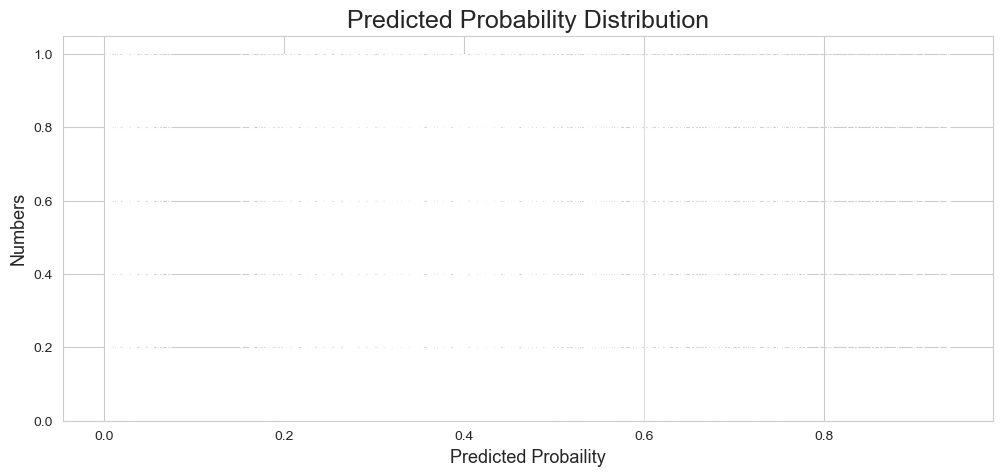

In [214]:
plt.figure(num=1, figsize = (12, 5))
plt.hist(pred, bins = 100)
plt.title('Predicted Probability Distribution', size = 18)
plt.ylabel('Numbers', size = 13)
plt.xlabel('Predicted Probaility', size = 13)
plt.show()

In [215]:
#

_______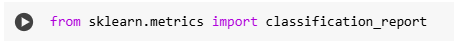

In [216]:
from sklearn.metrics import classification_report

In [217]:
#

_____________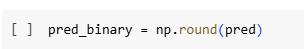

In [218]:
pred_binary = np.round(pred)

In [219]:
#

_________________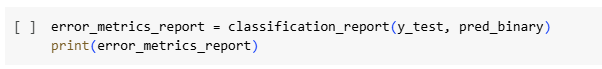

In [220]:
error_metrics_report = classification_report(y_test, pred_binary)
print(error_metrics_report)

              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85      1058
         1.0       0.17      0.32      0.22       137

    accuracy                           0.75      1195
   macro avg       0.54      0.56      0.54      1195
weighted avg       0.82      0.75      0.78      1195



In [221]:
#

### Neural Network Hyperparameters' Optimisation

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [222]:
pip install keras_tuner

   ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --------- ----------------------------- 30.7/129.1 kB 163.8 kB/s eta 0:00:01
   --------- ----------------------------- 30.7/129.1 kB 163.8 kB/s eta 0:00:01
   ------------ -------------------------- 41.0/129.1 kB 130.7 kB/s eta 0:00:01
   ------------ -------------------------- 41.0/129.1 kB 130.7 kB/s eta 0:00:01
   ------------------ -------------------- 61.4/129.1 kB 156.1 kB/s eta 0:00:01
   ------------------------ -------------- 81.9/129.1 kB 191.1 kB/s eta 0:00:01
   --------------------------- ----------- 92.2/129.1 kB 194.1 kB/s eta 0:00:01
   --------------------------- ----------- 92.2/129.1 kB 194.1 kB/s eta 0:00:01
 

DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\jiter-0.8.2-py3.12-win-amd64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\langchain_text_splitters-0.3.5-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\langsmith-0.3.2-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\mcqgenerator-0.0.1-py3.12.egg is depre

_________________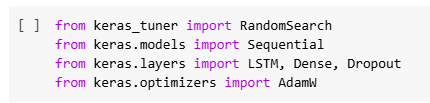

In [223]:
from keras_tuner import RandomSearch
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import AdamW

In [224]:
#

_____________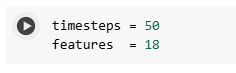

In [225]:
timesteps = 50
features = 18

In [226]:
#

_______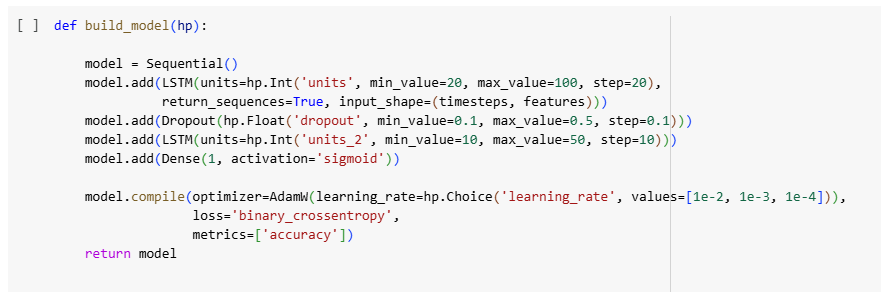

In [231]:
def build_model(hp):
  model = Sequential()
  model.add(LSTM(units = hp.Int('units', min_value = 20, max_value = 100, step=20),
                 return_sequences = True, input_shape = (timesteps, features)))
  model.add(Dropout(hp.Float('dropout', min_value = 0.1, max_value = 0.5, step = 0.1)))
  model.add(LSTM(units = hp.Int('units_2', min_value = 10, max_value = 50, step=10)))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(optimizer=AdamW(learning_rate=hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])),
                loss = 'binary_crossentropy',
                metrics = ['accuracy']
                )
  return model

In [ ]:
#

__________________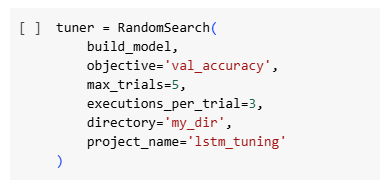

In [232]:
tuner = RandomSearch(build_model,
                     objective='val_accuracy',
                     max_trials=5,
                     executions_per_trial = 3,
                     directory = 'my_dir',
                     project_name = 'lstm_tuning')

c:\Users\aazhm\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#

Reloading Tuner from my_dir/lstm_tuning/tuner0.json


___________________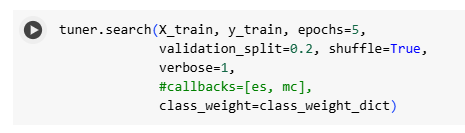

In [235]:
tuner.search(X_train, y_train,epochs = 5,
             validation_split = 0.2, shuffle = True,
             verbose = 1, class_weight = class_weight_dict)

Trial 5 Complete [00h 02m 03s]
val_accuracy: 0.8225631316502889

Best val_accuracy So Far: 0.8225631316502889
Total elapsed time: 00h 05m 44s


In [ ]:
#

Trial 5 Complete [00h 00m 54s]
val_accuracy: 0.2907174949844678

Best val_accuracy So Far: 0.9325894713401794
Total elapsed time: 00h 06m 44s


__________________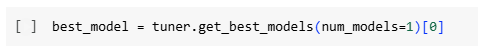

In [236]:
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\aazhm\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\aazhm\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
#

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


_________________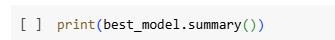

In [237]:
print(best_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 100)        │        47,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │        15,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,351 (247.46 KB)

 Trainable params: 63,351 (247.46 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50, 40)              │           9,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 40)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          18,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,075 (324.52 KB)

 Trainable params: 27,691 (108.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 55,384 (216.35 KB)

None


# Lab Logbook Requirement:

<html> <h3 style="; color:blue;">
   
1) Modify the training parameter of the optimised best LSTM model using the following formulas:

Modify the number of epochs:
Z + 30
, where your SID is: XXXXXXZ

Modify the batch_size:
Z + 10
, where your SID is: XXXXXXZ

2) Leave other parameters the same as in the practical session.
3) Use EarlyStopping() and ModelCheckpoint() functions.
4) Train the optimised best LSTM model with the same datasets and your training parameters.
5) Calculate and demonstrate the received test Accuracy and other error metrics for the classification task.
6) Plot the "More detailed Accuracy" graph.
7) Please only add to your Lab Logbook print-screens of:
- code your Use EarlyStopping() and ModelCheckpoint() functions
- code and training result using model.fit()
- the resulting test Accuracy and other error metrics for the classification task using classification_report().
- Accuracy detailed graph
    
</h3> </html>

<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.
</h3> </html>

In [246]:
epochs = 33
batch_size = 13

In [238]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [242]:
ec = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
mc = ModelCheckpoint('best_model_LSTM.keras', monitor='val_loss', mode = 'min', verbose=1, save_best_only=True)


In [243]:
best_model.fit?

Signature:
best_model.fit(
    x=None,
    y=None,
    batch_size=None,
    epochs=1,
    verbose='auto',
    callbacks=None,
    validation_split=0.0,
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1,
)
Docstring:
Trains the model for a fixed number of epochs (dataset iterations).

Args:
    x: Input data. It could be:
        - A NumPy array (or array-like), or a list of arrays
        (in case the model has multiple inputs).
        - A tensor, or a list of tensors
        (in case the model has multiple inputs).
        - A dict mapping input names to the corresponding array/tensors,
        if the model has named inputs.
        - A `tf.data.Dataset`. Should return a tuple
        of either `(inputs, targets)` or
        `(inputs, targets, sample_weights)`.
        - A `keras.utils.PyDataset` returning `(inputs,
 

In [248]:
history2 = best_model.fit(X_train, y_train,
                          validation_split = 0.2,
                          epochs = epochs,
                          batch_size = batch_size,
                          callbacks = [ec, mc],
                          verbose = 1,
                          shuffle = True,
                          class_weight = class_weight_dict)

Epoch 1/33
661/662 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3499 - loss: 0.7259
Epoch 1: val_loss improved from inf to 0.78852, saving model to best_model_LSTM.keras
662/662 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.3498 - loss: 0.7259 - val_accuracy: 0.0674 - val_loss: 0.7885
Epoch 2/33
660/662 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3249 - loss: 0.7215
Epoch 2: val_loss improved from 0.78852 to 0.74980, saving model to best_model_LSTM.keras
662/662 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.3252 - loss: 0.7215 - val_accuracy: 0.3398 - val_loss: 0.7498
Epoch 3/33
662/662 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5552 - loss: 0.6869
Epoch 3: val_loss improved from 0.74980 to 0.60374, saving model to best_model_LSTM.keras
662/662 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5552 - loss: 0.6869 - val_accuracy: 0.8047 - val_loss: 0.6037
Epoch 4/33
661/662 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5972 - loss: 0.6807
Epoch 4: val_loss improved fr

In [255]:
pred2 = best_model.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [256]:
best_model_pred = np.round(pred2)

In [258]:
clf = classification_report(y_test, best_model_pred)
print(clf)

              precision    recall  f1-score   support

         0.0       1.00      0.53      0.69      1058
         1.0       0.22      1.00      0.36       137

    accuracy                           0.58      1195
   macro avg       0.61      0.77      0.52      1195
weighted avg       0.91      0.58      0.66      1195



Text(0.5, 1.0, 'Detailed Accuracy graph')

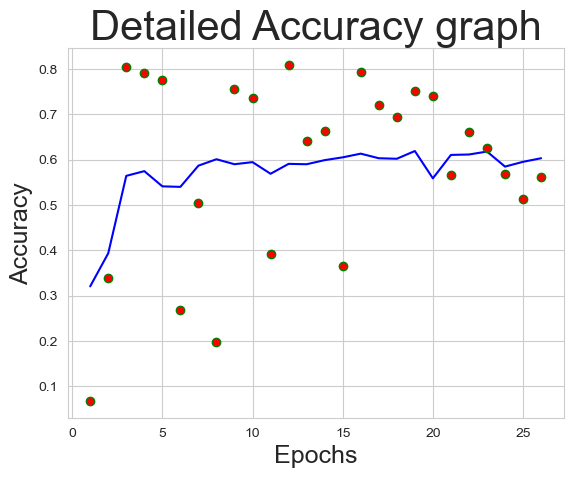

In [264]:
history_dict = history2.history
accuracy = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, accuracy, 'b', label = 'Training Accuracy')
plt.plot(epochs, val_acc, 'o',markeredgecolor = 'green', markerfacecolor='red', label = 'Training Accuracy')
plt.xlabel('Epochs', size =18)
plt.ylabel('Accuracy', size = 18)
plt.title('Detailed Accuracy graph')


